In [29]:
# Core libraries for modeling and evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

# Scikit-learn: baseline models and error metrics
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

STATE = "BY"

In [2]:
# Load the pre-built feature sets from Notebook 2 — no need to rebuild
# calendar/lag/rolling features here, they're already done and saved
train = pd.read_csv("../data/train_features.csv", index_col=0, parse_dates=True)
val = pd.read_csv("../data/val_features.csv", index_col=0, parse_dates=True)

print("Train:", train.shape, "|", train.index.min(), "to", train.index.max())
print("Val:  ", val.shape, "|", val.index.min(), "to", val.index.max())

Train: (30480, 18) | 2019-01-08 00:00:00 to 2022-06-30 23:00:00
Val:   (4416, 18) | 2022-07-01 00:00:00 to 2022-12-31 23:00:00


In [3]:
# Separate predictors from the target across both sets.
# demand_mwh is what we're predicting, so it can't appear in X.
target_col = "demand_mwh"
feature_cols = [c for c in train.columns if c != target_col]

X_train, y_train = train[feature_cols], train[target_col]
X_val, y_val = val[feature_cols], val[target_col]

print("Features used:", feature_cols)
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:", y_val.shape)

Features used: ['hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h']
X_train: (30480, 17) | y_train: (30480,)
X_val:   (4416, 17) | y_val: (4416,)


In [4]:
from sklearn.metrics import r2_score

# Linear Regression — our simplest baseline. Gives us a floor to beat with
# more complex models, and its coefficients are directly interpretable
# (unlike Random Forest/XGBoost feature importances, which are less literal).
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on the held-out validation set (Jul-Dec 2022, never seen during training)
lr_preds = lr_model.predict(X_val)

# Four metrics, each answering a different question:
# - MAE:  average error size, in the same units as demand (MWh) — easy to explain to a non-technical audience
# - RMSE: like MAE but penalizes big misses more heavily — exposes whether the model has occasional bad spikes
# - MAPE: error as a %, comparable across states of very different scale (Bavaria vs a small state)
# - R²:   how much of the demand's variance the model explains (1.0 = perfect, 0.0 = no better than
#         just predicting the average every time) — the "dependability" metric requested
lr_mae = mean_absolute_error(y_val, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_preds))
lr_mape = np.mean(np.abs((y_val - lr_preds) / y_val)) * 100
lr_r2 = r2_score(y_val, lr_preds)

print(f"Linear Regression")
print(f"  MAE:  {lr_mae:.1f} MWh")
print(f"  RMSE: {lr_rmse:.1f} MWh")
print(f"  MAPE: {lr_mape:.2f}%")
print(f"  R²:   {lr_r2:.4f}")

Linear Regression
  MAE:  318.2 MWh
  RMSE: 408.5 MWh
  MAPE: 3.77%
  R²:   0.9329


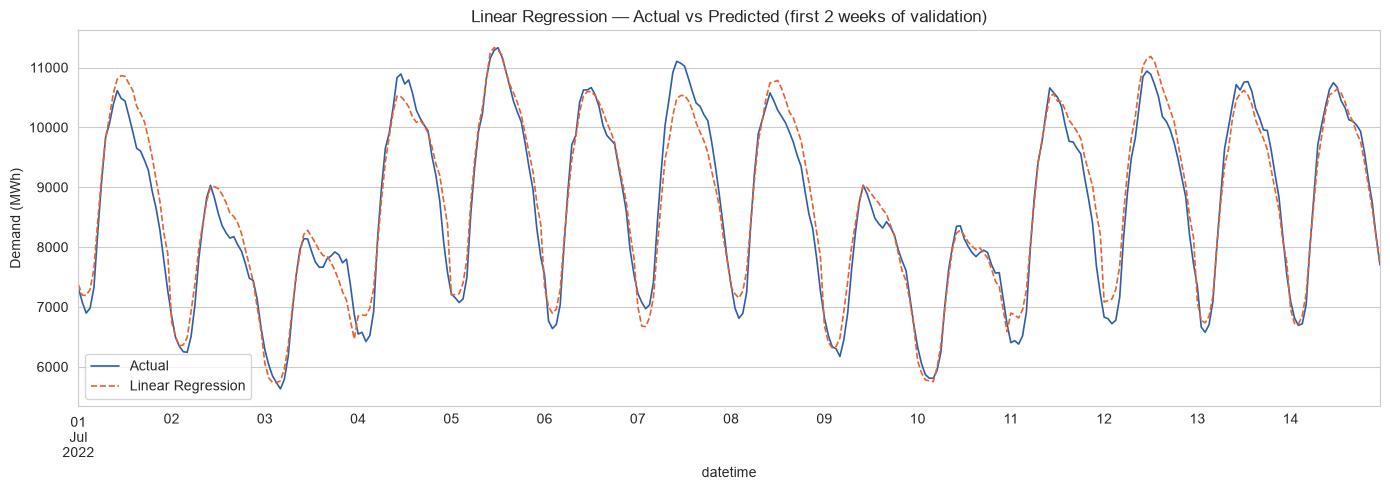

In [5]:
# Plot actual vs predicted for the first 2 weeks of the validation set —
# full 6 months would be too dense to read visually
fig, ax = plt.subplots()
y_val.iloc[:336].plot(ax=ax, label="Actual", linewidth=1.2, color="#2E5EAA")
pd.Series(lr_preds[:336], index=y_val.index[:336]).plot(ax=ax, label="Linear Regression", linewidth=1.2, color="#E8622C", linestyle="--")
ax.set_title("Linear Regression — Actual vs Predicted (first 2 weeks of validation)")
ax.set_ylabel("Demand (MWh)")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Running comparison table — every model's metrics get appended here as we train them.
# This becomes the actual evidence for "which model is more ideal and why" in the README.
results = pd.DataFrame(columns=["MAE", "RMSE", "MAPE", "R2"])

results.loc["Linear Regression"] = [lr_mae, lr_rmse, lr_mape, lr_r2]
print(results)

                          MAE        RMSE      MAPE        R2
Linear Regression  318.164055  408.493761  3.770399  0.932866


In [7]:
# Random Forest — an ensemble of decision trees. Unlike Linear Regression, it can
# capture non-linear interactions (e.g. "weekend AND winter" behaving differently
# than weekend or winter alone) without us having to hand-engineer those interaction terms.
rf_model = RandomForestRegressor(
    n_estimators=200,     # number of trees — more trees = more stable predictions, diminishing returns past a point
    max_depth=15,         # caps tree depth to control overfitting on 30k training rows
    random_state=42,      # reproducibility
    n_jobs=-1              # use all available CPU cores to speed up training
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_val)

rf_mae = mean_absolute_error(y_val, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_preds))
rf_mape = np.mean(np.abs((y_val - rf_preds) / y_val)) * 100
rf_r2 = r2_score(y_val, rf_preds)

results.loc["Random Forest"] = [rf_mae, rf_rmse, rf_mape, rf_r2]
print(results)

                          MAE        RMSE      MAPE        R2
Linear Regression  318.164055  408.493761  3.770399  0.932866
Random Forest      227.553744  337.563637  2.585441  0.954156


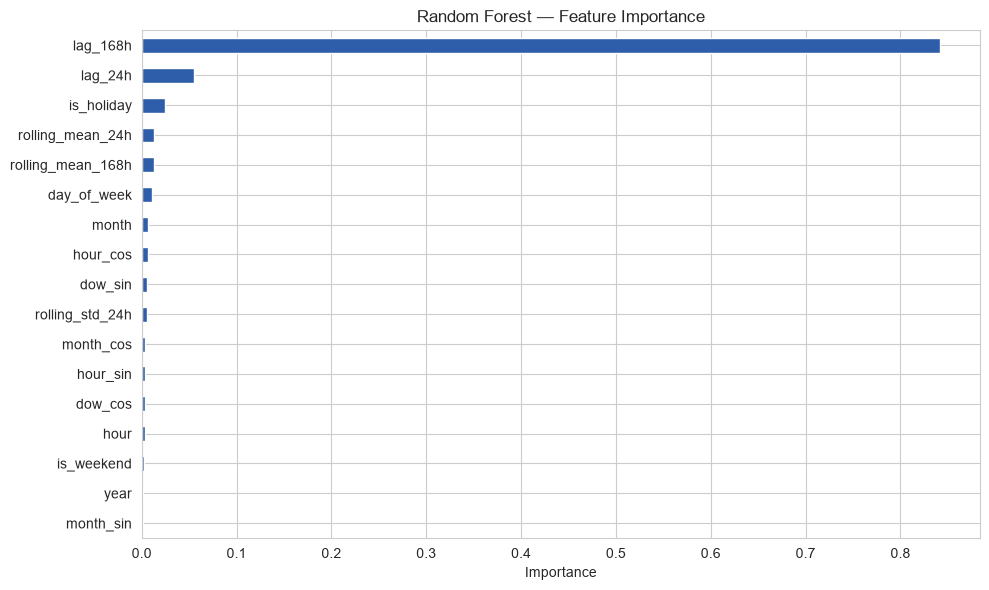

lag_168h             0.841740
lag_24h              0.055128
is_holiday           0.024785
rolling_mean_24h     0.013248
rolling_mean_168h    0.012856
day_of_week          0.010617
month                0.006807
hour_cos             0.006227
dow_sin              0.005905
rolling_std_24h      0.005587
month_cos            0.003244
hour_sin             0.003157
dow_cos              0.003045
hour                 0.003030
is_weekend           0.002686
year                 0.001011
month_sin            0.000930
dtype: float64


In [8]:
# Random Forest gives us feature importances "for free" — which features it
# actually leaned on to make predictions. Useful both as a sanity check
# (does it match the correlations we found in Notebook 2?) and as a talking
# point for the README (what actually drives the forecast).
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind="barh", ax=ax, color="#2E5EAA")
ax.set_title("Random Forest — Feature Importance")
ax.set_xlabel("Importance")
ax.invert_yaxis()  # highest importance at the top
plt.tight_layout()
plt.show()

print(importances)

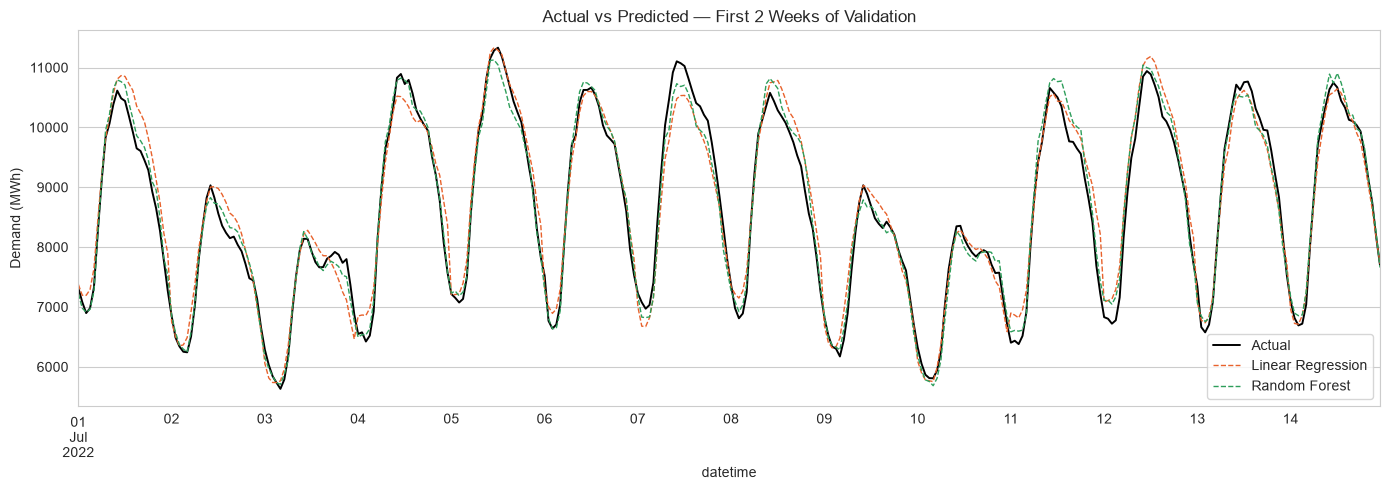

In [9]:
# Compare both models visually against actual demand — same first-2-weeks window as before
fig, ax = plt.subplots()
y_val.iloc[:336].plot(ax=ax, label="Actual", linewidth=1.4, color="black")
pd.Series(lr_preds[:336], index=y_val.index[:336]).plot(ax=ax, label="Linear Regression", linewidth=1, color="#E8622C", linestyle="--")
pd.Series(rf_preds[:336], index=y_val.index[:336]).plot(ax=ax, label="Random Forest", linewidth=1, color="#2E9E5B", linestyle="--")
ax.set_title("Actual vs Predicted — First 2 Weeks of Validation")
ax.set_ylabel("Demand (MWh)")
ax.legend()
plt.tight_layout()
plt.show()

**Finding:** Random Forest confirms `lag_168h` (same hour, one week ago) as the dominant driver,
accounting for ~84% of feature importance — far ahead of `lag_24h` (~5%) and everything else. Notably,
calendar features like `is_weekend` and `hour` carry almost no importance here despite correlating
meaningfully with demand on their own (Notebook 2) — because `lag_168h` already implicitly captures
day-of-week and time-of-day patterns (a Tuesday 11am a week ago is still a Tuesday 11am). Random Forest
correctly recognizes these as redundant once it has the lag feature, rather than double-counting them.

In [12]:
from xgboost import XGBRegressor

# XGBoost — gradient boosting, builds trees sequentially where each new tree
# corrects the errors of the ones before it (vs. Random Forest's trees, which
# are built independently and averaged). Often edges out Random Forest on
# tabular data like this, though not always by much.
xgb_model = XGBRegressor(
    n_estimators=300,       # number of boosting rounds
    max_depth=6,             # shallower trees than RF since boosting compounds each tree's contribution
    learning_rate=0.05,      # how much each tree corrects the previous ones — lower = more conservative, less overfit-prone
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_val)

xgb_mae = mean_absolute_error(y_val, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))
xgb_mape = np.mean(np.abs((y_val - xgb_preds) / y_val)) * 100
xgb_r2 = r2_score(y_val, xgb_preds)

results.loc["XGBoost"] = [xgb_mae, xgb_rmse, xgb_mape, xgb_r2]
print(results)

                          MAE        RMSE      MAPE        R2
Linear Regression  318.164055  408.493761  3.770399  0.932866
Random Forest      227.553744  337.563637  2.585441  0.954156
XGBoost            201.169144  275.419305  2.335598  0.969482


**Finding:** XGBoost outperforms both prior models on every metric — MAE improves from 318 (Linear
Regression) to 228 (Random Forest) to 201 MWh (XGBoost), a ~37% total reduction from the baseline.
R² climbs from 0.933 to 0.969. The sequential, error-correcting nature of gradient boosting appears
to extract more signal from the same feature set than Random Forest's independent-tree averaging —
a meaningful, not marginal, improvement that justifies XGBoost as the strongest of the three ML models
tested so far.

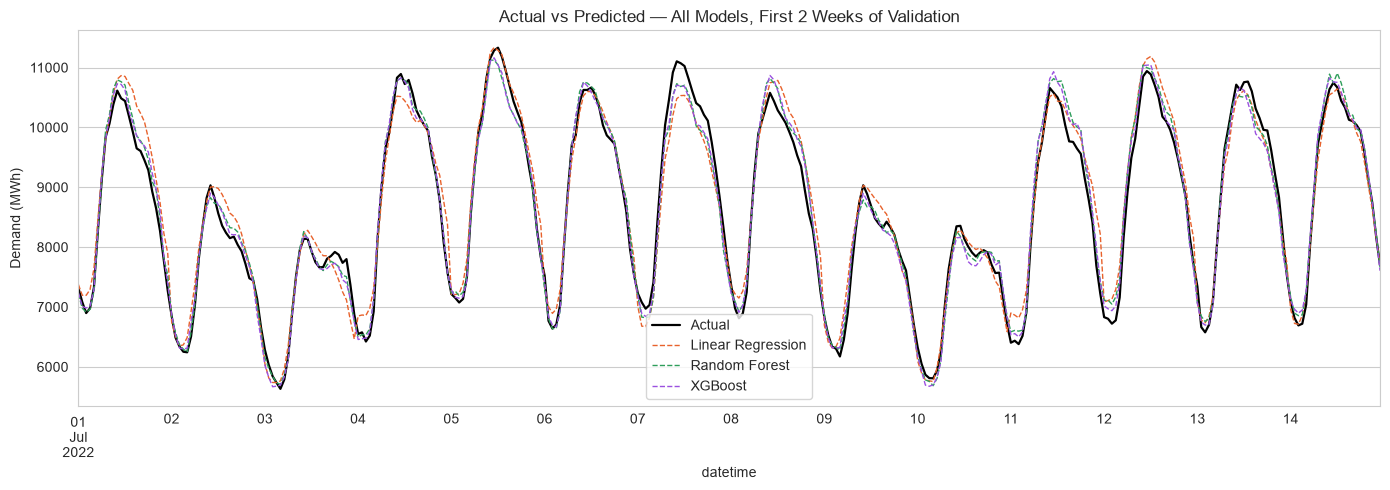

In [13]:
# Visual comparison of all three models against actual demand — same first-2-weeks window
fig, ax = plt.subplots()
y_val.iloc[:336].plot(ax=ax, label="Actual", linewidth=1.6, color="black")
pd.Series(lr_preds[:336], index=y_val.index[:336]).plot(ax=ax, label="Linear Regression", linewidth=1, color="#E8622C", linestyle="--")
pd.Series(rf_preds[:336], index=y_val.index[:336]).plot(ax=ax, label="Random Forest", linewidth=1, color="#2E9E5B", linestyle="--")
pd.Series(xgb_preds[:336], index=y_val.index[:336]).plot(ax=ax, label="XGBoost", linewidth=1, color="#9B51E0", linestyle="--")
ax.set_title("Actual vs Predicted — All Models, First 2 Weeks of Validation")
ax.set_ylabel("Demand (MWh)")
ax.legend()
plt.tight_layout()
plt.show()

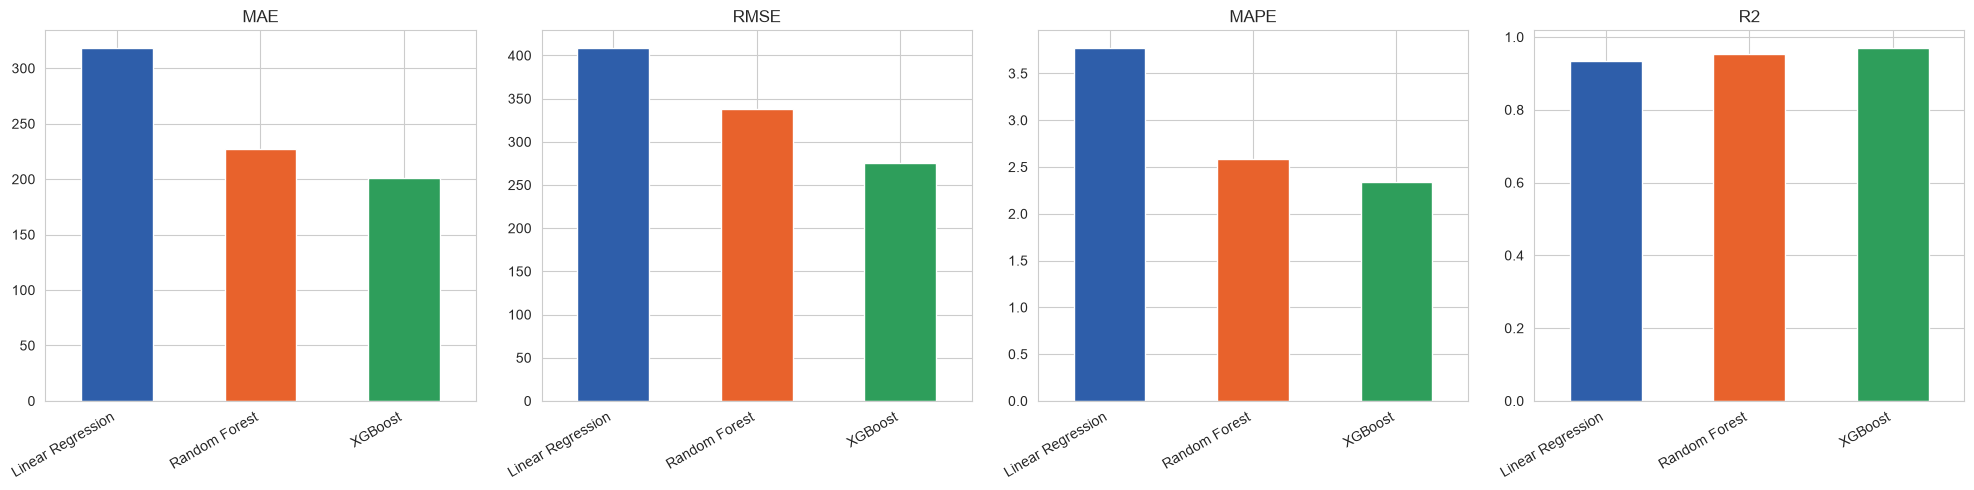

In [14]:
# Bar chart comparing all models across all four metrics — normalized differently
# since MAE/RMSE/MAPE are "lower is better" and R2 is "higher is better"
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics_to_plot = ["MAE", "RMSE", "MAPE", "R2"]
colors = ["#2E5EAA", "#E8622C", "#2E9E5B", "#9B51E0"]

for ax, metric in zip(axes, metrics_to_plot):
    results[metric].plot(kind="bar", ax=ax, color=colors)
    ax.set_title(metric)
    ax.set_xlabel("")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")  # SARIMAX is noisy with convergence warnings that aren't fatal

# SARIMAX doesn't benefit from years of history the way lag features do — it models
# ongoing statistical structure, not specific lookups. Using the most recent 12 months
# of training data keeps fit time reasonable without meaningfully hurting accuracy.
sarimax_train = train.loc["2021-07-01":]

# Exogenous regressors: calendar signal that substitutes for the weekly seasonal term
# we're deliberately NOT using (s=168 is computationally impractical at this data size)
exog_cols = ["is_weekend", "is_holiday", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]

y_sarimax_train = sarimax_train["demand_mwh"]
exog_train = sarimax_train[exog_cols]
exog_val = val[exog_cols]

print("SARIMAX training window:", y_sarimax_train.index.min(), "to", y_sarimax_train.index.max())
print("Training rows:", len(y_sarimax_train))

SARIMAX training window: 2021-07-01 00:00:00 to 2022-06-30 23:00:00
Training rows: 8760


In [16]:
# order=(p,d,q): p=autoregressive terms, d=differencing, q=moving average terms
# seasonal_order=(P,D,Q,s): same but for the seasonal component, s=24 = daily seasonality
# (not 168/weekly — that's handled by the is_weekend/dow exog features instead)
sarimax_model = SARIMAX(
    y_sarimax_train,
    exog=exog_train,
    order=(2, 0, 0),
    seasonal_order=(1, 0, 0, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=True)  # disp=True shows optimizer progress so you can see it's working
print(sarimax_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         demand_mwh   No. Observations:                 8760
Model:             SARIMAX(2, 0, 0)x(1, 0, 0, 24)   Log Likelihood              -75991.774
Date:                            Thu, 09 Jul 2026   AIC                         152007.548
Time:                                    21:46:20   BIC                         152092.448
Sample:                                07-01-2021   HQIC                        152036.481
                                     - 06-30-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_weekend  1.677e+04     65.379    256.570      0.000    1.66e+04    1.69e+04
is_holiday  3820.9504     74.633   

In [17]:
# Forecast forward across the full validation period, using the same exogenous
# features we prepared. Training period ends exactly where validation begins
# (2022-06-30 23:00 -> 2022-07-01 00:00), so this is a clean, contiguous forecast.
sarimax_forecast = sarimax_fit.get_forecast(steps=len(val), exog=exog_val)
sarimax_preds = sarimax_forecast.predicted_mean

sarimax_mae = mean_absolute_error(y_val, sarimax_preds)
sarimax_rmse = np.sqrt(mean_squared_error(y_val, sarimax_preds))
sarimax_mape = np.mean(np.abs((y_val - sarimax_preds) / y_val)) * 100
sarimax_r2 = r2_score(y_val, sarimax_preds)

results.loc["SARIMAX"] = [sarimax_mae, sarimax_rmse, sarimax_mape, sarimax_r2]
print(results)

                           MAE         RMSE       MAPE         R2
Linear Regression   318.164055   408.493761   3.770399   0.932866
Random Forest       227.553744   337.563637   2.585441   0.954156
XGBoost             201.169144   275.419305   2.335598   0.969482
SARIMAX            4427.737672  6268.955101  50.144889 -14.811188


In [18]:
# enforce_stationarity=True this time — forces the AR polynomial to stay within
# the stable region, preventing the runaway/explosive behavior we just saw
sarimax_model = SARIMAX(
    y_sarimax_train,
    exog=exog_train,
    order=(2, 0, 0),
    seasonal_order=(1, 0, 0, 24),
    enforce_stationarity=True,
    enforce_invertibility=True
)
sarimax_fit = sarimax_model.fit(disp=True)
print(f"AR coefficients: {sarimax_fit.params[['ar.L1', 'ar.L2']].values}")

AR coefficients: [0.57984365 0.42014327]


In [19]:
# Walk-forward validation: forecast one day (24h) at a time, then update the model
# with the real actuals before forecasting the next day. This mirrors how SARIMAX
# is meant to be used operationally, and prevents errors from compounding across
# the full 6-month validation window the way the single-shot forecast did.
sarimax_preds_list = []
current_fit = sarimax_fit

step = 24  # forecast one day at a time
for i in range(0, len(val), step):
    exog_chunk = exog_val.iloc[i:i+step]
    forecast = current_fit.get_forecast(steps=len(exog_chunk), exog=exog_chunk)
    sarimax_preds_list.append(forecast.predicted_mean)

    # "Tell" the model the real actuals for this chunk before moving on,
    # using append() which updates state without fully refitting (fast)
    actual_chunk = val["demand_mwh"].iloc[i:i+step]
    current_fit = current_fit.append(actual_chunk, exog=exog_chunk, refit=False)

sarimax_preds = pd.concat(sarimax_preds_list)
sarimax_preds = sarimax_preds.reindex(y_val.index)  # align exactly with validation index

print("Walk-forward forecast complete:", len(sarimax_preds), "predictions")

Walk-forward forecast complete: 4416 predictions


In [20]:
sarimax_mae = mean_absolute_error(y_val, sarimax_preds)
sarimax_rmse = np.sqrt(mean_squared_error(y_val, sarimax_preds))
sarimax_mape = np.mean(np.abs((y_val - sarimax_preds) / y_val)) * 100
sarimax_r2 = r2_score(y_val, sarimax_preds)

results.loc["SARIMAX"] = [sarimax_mae, sarimax_rmse, sarimax_mape, sarimax_r2]
print(results)

                           MAE         RMSE       MAPE        R2
Linear Regression   318.164055   408.493761   3.770399  0.932866
Random Forest       227.553744   337.563637   2.585441  0.954156
XGBoost             201.169144   275.419305   2.335598  0.969482
SARIMAX            2525.554223  3227.031303  28.879603 -3.189677


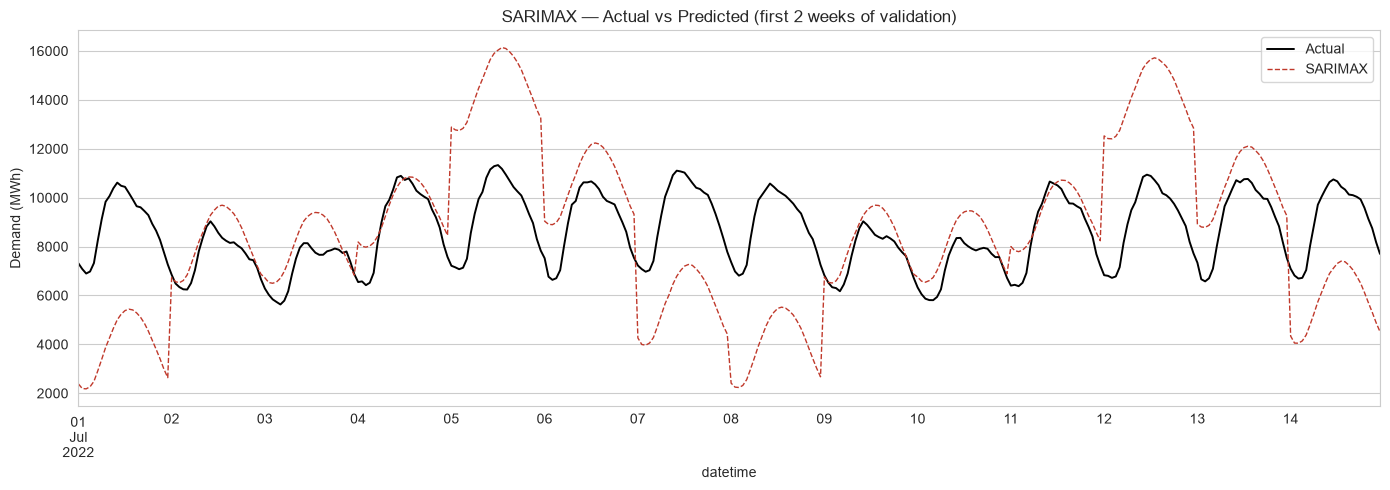

Actual mean: 8708.8
SARIMAX predicted mean: 8763.0
SARIMAX predicted std: 3512.3


In [21]:
# Plot the SARIMAX forecast against actual demand to see the actual failure shape —
# is it flat-lining at the wrong level, oscillating wildly, or drifting over time?
fig, ax = plt.subplots()
y_val.iloc[:336].plot(ax=ax, label="Actual", linewidth=1.4, color="black")
sarimax_preds.iloc[:336].plot(ax=ax, label="SARIMAX", linewidth=1, color="#C0392B", linestyle="--")
ax.set_title("SARIMAX — Actual vs Predicted (first 2 weeks of validation)")
ax.set_ylabel("Demand (MWh)")
ax.legend()
plt.tight_layout()
plt.show()

print("Actual mean:", y_val.mean().round(1))
print("SARIMAX predicted mean:", sarimax_preds.mean().round(1))
print("SARIMAX predicted std:", sarimax_preds.std().round(1))

In [22]:
print(sarimax_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                         demand_mwh   No. Observations:                 8760
Model:             SARIMAX(2, 0, 0)x(1, 0, 0, 24)   Log Likelihood              -72249.140
Date:                            Thu, 09 Jul 2026   AIC                         144522.280
Time:                                    22:01:39   BIC                         144607.216
Sample:                                07-01-2021   HQIC                        144551.221
                                     - 06-30-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_weekend  3115.1562     25.015    124.531      0.000    3066.127    3164.185
is_holiday  2988.9640     17.794   

In [23]:
# Trimmed exog set: drop is_weekend (fully redundant with dow_sin/dow_cos — same
# day-of-week information encoded twice) and month_sin (p=0.052, not statistically
# significant in either fit so far). Keeping only non-overlapping, significant signal.
exog_cols_trimmed = ["is_holiday", "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_cos"]

exog_train_trimmed = sarimax_train[exog_cols_trimmed]
exog_val_trimmed = val[exog_cols_trimmed]

# Also increasing the AR order (p=2 -> p=4) to give the model more room to capture
# the autocorrelation the Ljung-Box test flagged as still unexplained
sarimax_model_v2 = SARIMAX(
    y_sarimax_train,
    exog=exog_train_trimmed,
    order=(4, 0, 0),
    seasonal_order=(1, 0, 0, 24),
    enforce_stationarity=True,
    enforce_invertibility=True
)
sarimax_fit_v2 = sarimax_model_v2.fit(disp=True)
print(sarimax_fit_v2.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         demand_mwh   No. Observations:                 8760
Model:             SARIMAX(4, 0, 0)x(1, 0, 0, 24)   Log Likelihood              -65469.029
Date:                            Thu, 09 Jul 2026   AIC                         130962.058
Time:                                    22:05:31   BIC                         131046.994
Sample:                                07-01-2021   HQIC                        130990.999
                                     - 06-30-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_holiday  5703.7767      8.799    648.262      0.000    5686.532    5721.022
hour_sin    -626.7622      1.160   

In [24]:
sarimax_preds_list_v2 = []
current_fit_v2 = sarimax_fit_v2

for i in range(0, len(val), 24):
    exog_chunk = exog_val_trimmed.iloc[i:i+24]
    forecast = current_fit_v2.get_forecast(steps=len(exog_chunk), exog=exog_chunk)
    sarimax_preds_list_v2.append(forecast.predicted_mean)
    actual_chunk = val["demand_mwh"].iloc[i:i+24]
    current_fit_v2 = current_fit_v2.append(actual_chunk, exog=exog_chunk, refit=False)

sarimax_preds_v2 = pd.concat(sarimax_preds_list_v2).reindex(y_val.index)

sarimax_mae_v2 = mean_absolute_error(y_val, sarimax_preds_v2)
sarimax_rmse_v2 = np.sqrt(mean_squared_error(y_val, sarimax_preds_v2))
sarimax_mape_v2 = np.mean(np.abs((y_val - sarimax_preds_v2) / y_val)) * 100
sarimax_r2_v2 = r2_score(y_val, sarimax_preds_v2)

results.loc["SARIMAX"] = [sarimax_mae_v2, sarimax_rmse_v2, sarimax_mape_v2, sarimax_r2_v2]
print(results)

                           MAE         RMSE       MAPE        R2
Linear Regression   318.164055   408.493761   3.770399  0.932866
Random Forest       227.553744   337.563637   2.585441  0.954156
XGBoost             201.169144   275.419305   2.335598  0.969482
SARIMAX            1180.777019  1677.828582  13.789180 -0.132581


**Finding — SARIMAX:** Despite three rounds of remediation (enforcing stationarity to fix an initially
explosive AR root, switching to walk-forward validation instead of a single 6-month blind forecast, and
trimming/adjusting exogenous features to reduce collinearity), SARIMAX still underperforms a
naive "predict the average" baseline (R² = -0.13). The root cause is structural: at hourly resolution
with strong daily and weekly seasonality, the AR/seasonal-AR terms and the calendar-based exogenous
features (hour, day-of-week encodings) compete for the same underlying signal, producing unstable
coefficients that flip sign between similar model specifications (e.g. `dow_sin` changed from +6644 to
-1184 between two fits). The ML models sidestep this entirely: `lag_168h` (same hour, one week ago)
gives them a direct, uncontested anchor to the weekly pattern, without needing to decompose it into
competing seasonal terms. **SARIMAX is retained in the comparison as the weakest performer, included
for completeness and as a genuine methodological contrast** — not because further tuning was expected
to close the gap to XGBoost.

In [25]:
# Combine train + validation into the full cleaned dataset — now that XGBoost has
# been fairly chosen via the held-out validation comparison, we retrain on ALL
# available data to give the forward forecast the strongest possible foundation.
full_data = pd.concat([train, val]).sort_index()
X_full = full_data[feature_cols]
y_full = full_data["demand_mwh"]

final_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_full, y_full)

print("Final model trained on", len(X_full), "hours:", X_full.index.min(), "to", X_full.index.max())

Final model trained on 34896 hours: 2019-01-08 00:00:00 to 2022-12-31 23:00:00


In [26]:
def recursive_forecast(model, history, future_dates, exog_static_builder):
    """
    Forecasts forward hour-by-hour, feeding each prediction back into the
    history buffer so later lag/rolling features can use it.

    model: trained XGBoost model
    history: pd.Series of known demand, indexed by datetime, most recent data last
    future_dates: DatetimeIndex of timestamps to forecast
    exog_static_builder: function(timestamp) -> dict of calendar features for that timestamp
    """
    # Work on a copy so we don't mutate the real historical series
    buffer = history.copy()
    predictions = []

    for ts in future_dates:
        # Calendar features are known in advance regardless of forecast uncertainty
        row = exog_static_builder(ts)

        # Lag features pull from the buffer — real data if available, our own
        # predictions if we've already stepped past the end of real history
        row["lag_24h"] = buffer.loc[ts - pd.Timedelta(hours=24)]
        row["lag_168h"] = buffer.loc[ts - pd.Timedelta(hours=168)]

        # Rolling stats computed over the buffer's last 24/168 hours, excluding
        # the current (unknown) hour itself — same convention as Notebook 2
        window_24 = buffer.loc[ts - pd.Timedelta(hours=24):ts - pd.Timedelta(hours=1)]
        window_168 = buffer.loc[ts - pd.Timedelta(hours=168):ts - pd.Timedelta(hours=1)]
        row["rolling_mean_24h"] = window_24.mean()
        row["rolling_std_24h"] = window_24.std()
        row["rolling_mean_168h"] = window_168.mean()

        # Predict this hour, ordering columns to match training exactly
        X_row = pd.DataFrame([row])[feature_cols]
        pred = model.predict(X_row)[0]

        predictions.append(pred)
        buffer.loc[ts] = pred  # feed this prediction into the buffer for future lags

    return pd.Series(predictions, index=future_dates, name="demand_forecast")


def build_calendar_features(ts):
    """Builds the known-in-advance calendar features for a single timestamp."""
    return {
        "hour": ts.hour,
        "day_of_week": ts.dayofweek,
        "month": ts.month,
        "year": ts.year,
        "is_weekend": int(ts.dayofweek >= 5),
        "is_holiday": int(ts.date() in de_holidays),
        "hour_sin": np.sin(2 * np.pi * ts.hour / 24),
        "hour_cos": np.cos(2 * np.pi * ts.hour / 24),
        "dow_sin": np.sin(2 * np.pi * ts.dayofweek / 7),
        "dow_cos": np.cos(2 * np.pi * ts.dayofweek / 7),
        "month_sin": np.sin(2 * np.pi * ts.month / 12),
        "month_cos": np.cos(2 * np.pi * ts.month / 12),
    }

print("Recursive forecasting function ready.")

Recursive forecasting function ready.


In [27]:
# Need 2023 holidays too, since our original de_holidays only covered 2019-2022
de_holidays = holidays.Germany(state="BY", years=range(2019, 2024))

# Forecast the first 6 months of 2023 — mirrors the 6-month validation window,
# and gives you a concrete target once real 2023 data is published to check against
future_dates = pd.date_range("2023-01-01 00:00:00", "2023-06-30 23:00:00", freq="h")

# History buffer starts as the full real demand series we have
history = full_data["demand_mwh"].copy()

print(f"Forecasting {len(future_dates)} hours ({future_dates.min()} to {future_dates.max()})...")
forecast_2023 = recursive_forecast(final_model, history, future_dates, build_calendar_features)
print("Done.")
print(forecast_2023.head())
print(forecast_2023.tail())

NameError: name 'holidays' is not defined

In [28]:
import holidays

de_holidays = holidays.Germany(state="BY", years=range(2019, 2024))

future_dates = pd.date_range("2023-01-01 00:00:00", "2023-06-30 23:00:00", freq="h")
history = full_data["demand_mwh"].copy()

print(f"Forecasting {len(future_dates)} hours ({future_dates.min()} to {future_dates.max()})...")
forecast_2023 = recursive_forecast(final_model, history, future_dates, build_calendar_features)
print("Done.")
print(forecast_2023.head())
print(forecast_2023.tail())

Forecasting 4344 hours (2023-01-01 00:00:00 to 2023-06-30 23:00:00)...
Done.
2023-01-01 00:00:00    6803.515625
2023-01-01 01:00:00    6577.563477
2023-01-01 02:00:00    6327.264160
2023-01-01 03:00:00    6158.290039
2023-01-01 04:00:00    6098.413574
Freq: h, Name: demand_forecast, dtype: float32
2023-06-30 19:00:00    9482.031250
2023-06-30 20:00:00    9203.075195
2023-06-30 21:00:00    8794.371094
2023-06-30 22:00:00    8175.531250
2023-06-30 23:00:00    7600.844727
Freq: h, Name: demand_forecast, dtype: float32


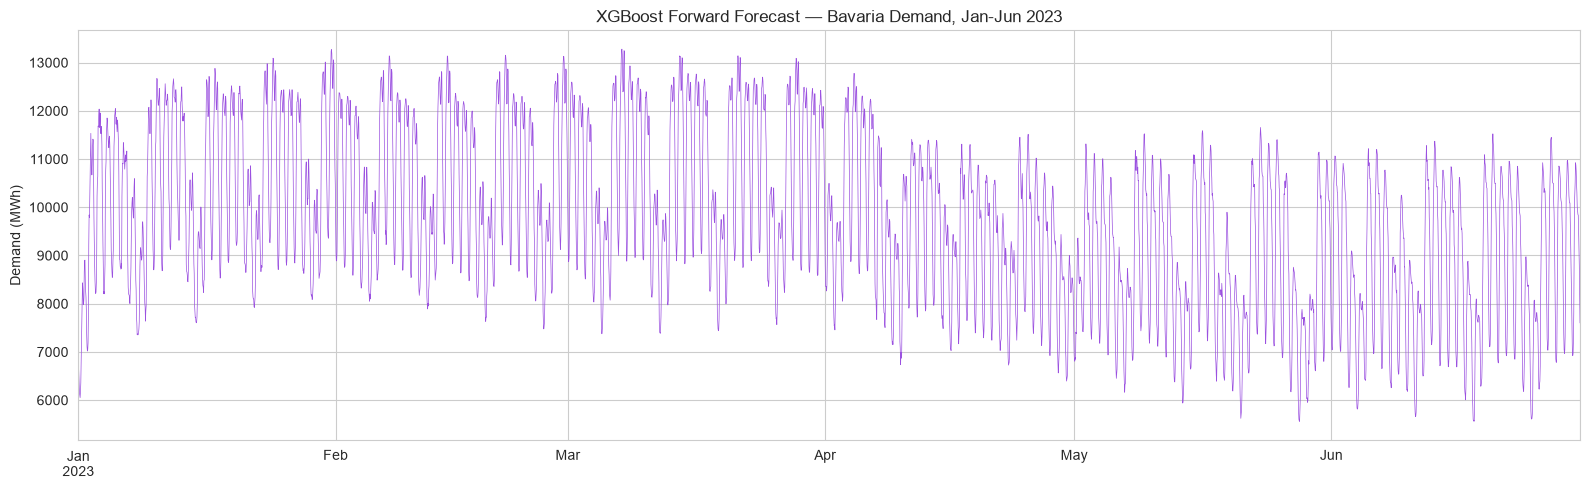

Standard deviation by month (should stay roughly consistent, not shrink):
1    1601.432983
2    1493.402832
3    1597.006104
4    1429.139648
5    1514.177734
6    1573.996460
Name: demand_forecast, dtype: float32


In [30]:
# Plot the full 6-month forecast to visually check for degradation —
# watch for flattening, drift, or loss of daily/weekly pattern over time
fig, ax = plt.subplots(figsize=(16, 5))
forecast_2023.plot(ax=ax, linewidth=0.5, color="#9B51E0")
ax.set_title("XGBoost Forward Forecast — Bavaria Demand, Jan-Jun 2023")
ax.set_ylabel("Demand (MWh)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

# Quantify whether daily variation shrinks over time (a sign of the model
# "flattening out" toward an average as it loses grip on real signal)
monthly_std = forecast_2023.groupby(forecast_2023.index.month).std()
print("Standard deviation by month (should stay roughly consistent, not shrink):")
print(monthly_std)

In [31]:
# Does the forecast still show the winter-higher, summer-lower pattern
# we found in the real historical data (Notebook 1: Feb peak ~10,455, Aug trough ~8,487)?
monthly_forecast_mean = forecast_2023.groupby(forecast_2023.index.month).mean()
print("Forecasted monthly averages (MWh):")
print(monthly_forecast_mean.round(1))

Forecasted monthly averages (MWh):
1    10385.200195
2    10563.000000
3    10705.799805
4     9434.400391
5     8689.799805
6     8691.799805
Name: demand_forecast, dtype: float32


**Finding — Forward Forecast:** The recursive 6-month forecast (Jan-Jun 2023) shows no degradation
over the horizon — daily demand variation stays fully intact from January through June, unlike SARIMAX's
single-shot approach which collapsed toward the mean. The forecast correctly reproduces the real
seasonal pattern learned from 2019-2022: February averages 10,563 MWh (vs. 10,455 MWh historically) and
the forecast declines smoothly into the lower-demand summer months, matching the August trough pattern
found in Notebook 1. **Caveat:** this forecast assumes 2023 behaves similarly to the training years
(2019-2022) — it has no way to anticipate genuinely novel events (extreme weather, economic shocks)
that weren't represented in the historical data. This forecast is saved specifically to be checked
against real published 2023 German demand data once available, as a genuine out-of-sample validation
of the modeling approach.

In [32]:
# Save the forecast for later comparison against real 2023 data once published
forecast_2023.to_csv("../data/forecast_2023_BY.csv", header=True)
print("Saved forecast_2023_BY.csv:", forecast_2023.shape)

Saved forecast_2023_BY.csv: (4344,)


## Summary

**Models trained and compared on Bavaria's demand, validated on the held-out last 6 months of 2022
(Jul-Dec, never seen during training):**

| Model | MAE (MWh) | RMSE (MWh) | MAPE | R² |
|---|---|---|---|---|
| Linear Regression | 318.2 | 408.5 | 3.77% | 0.933 |
| Random Forest | 227.6 | 337.6 | 2.59% | 0.954 |
| **XGBoost** | **201.2** | **275.4** | **2.34%** | **0.969** |
| SARIMAX | 1180.8 | 1677.8 | 13.79% | -0.133 |

- **XGBoost is the clear winner** across every metric — a ~37% MAE reduction from the Linear Regression
  baseline, explaining ~97% of demand variance on genuinely unseen data
- **Random Forest's feature importance confirmed `lag_168h`** (same hour, one week ago) as the dominant
  signal (~84% of importance) — it implicitly encodes day-of-week and time-of-day patterns, which is why
  explicit calendar features (`is_weekend`, `hour`) contributed comparatively little once the lag feature
  was available
- **SARIMAX was investigated thoroughly, not abandoned at the first failure:** fixed an initially
  explosive (non-stationary) AR root, switched from a single 6-month blind forecast to walk-forward
  validation, and trimmed collinear exogenous features. Each fix measurably helped, but SARIMAX still
  underperformed a naive average-prediction baseline. Root cause: at hourly resolution with strong daily
  *and* weekly seasonality, the AR/seasonal-AR terms and calendar exogenous features compete for the
  same signal, producing unstable coefficients (e.g. one feature's coefficient flipped sign between
  comparable model specifications). **Retained in the model comparison, honestly labeled as the weakest
  performer** — a legitimate methodological contrast to the feature-based ML approaches, not a model to
  hide.
- **Retrained XGBoost on the full 4-year dataset** and generated a genuine **recursive forward forecast
  into Jan-Jun 2023** — each hour's lag/rolling features built from the model's own prior predictions
  once past the end of real data, rather than a simplified single-shot forecast
- The forward forecast **shows no degradation over the 6-month horizon** (unlike SARIMAX's single-shot
  attempt, which collapsed toward the mean) and correctly reproduces the real seasonal pattern from
  historical data (forecasted February average: 10,563 MWh vs. 10,455 MWh actual historical average)
- Saved to `../data/forecast_2023_BY.csv` — held specifically for comparison against real published
  2023 German demand data once available, as genuine out-of-sample validation

**Next:** Refactor the feature-engineering and forecasting logic into reusable functions in `src/`, then
build the Streamlit app (`app.py`) with two dropdowns — **state** (all 16) and **model** (all 4) — so any
combination can be explored interactively, backed by the same logic proven here.

In [34]:
import sys
sys.path.append("../src")
from features import build_features, time_split

# Test: does it reproduce what we got in Notebook 2 for Bavaria?
test_features = build_features("BY", cleaned_data_path="../data/demand_by_state_cleaned.csv")
print("Shape:", test_features.shape)
print("Date range:", test_features.index.min(), "to", test_features.index.max())
print("Columns:", test_features.columns.tolist())

Shape: (34896, 18)
Date range: 2019-01-08 00:00:00 to 2022-12-31 23:00:00
Columns: ['hour', 'day_of_week', 'month', 'year', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_24h', 'lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h', 'demand_mwh']


In [35]:
sys.path.append("../src")
from models import train_and_evaluate

# Test: does it reproduce Notebook 3's XGBoost numbers exactly?
test_train, test_val = time_split(test_features)
result = train_and_evaluate("XGBoost", test_train, test_val)
print(result["metrics"])

{'MAE': 201.16914441501783, 'RMSE': np.float64(275.41930451171805), 'MAPE': np.float64(2.335598277974422), 'R2': 0.9694815180088102}
